Install + verify all three datasets are visible

In [1]:
import torch
print(f"Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Allocated: 0.00 GB


In [2]:
import os

print("=== Top level of /kaggle/input ===")
for item in os.listdir('/kaggle/input'):
    print(item)

print("\n=== Recursive walk, all levels ===")
for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

=== Top level of /kaggle/input ===
datasets

=== Recursive walk, all levels ===
/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/redwanahmed2025
/kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3
/kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final
/kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final/val_images
/kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final/train_images
/kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final/val
/kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final/val/labels
/kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final/test
/kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final/test/labels
/kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final/train
/kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final/train/labels
/k

In [3]:
checkpoint_dir = '/kaggle/input/datasets/redwanahmed2025/groupj-partb-ssl-checkpoints'
print(os.listdir(checkpoint_dir))

['simclr_loss_curve.png', 'simclr_backbone_epoch15.pt', 'simclr_backbone_epoch30.pt', 'simclr_backbone_epoch10.pt', 'simclr_tsne.png', 'simclr_backbone.pt', 'simclr_backbone_epoch25.pt', 'simclr_backbone_epoch5.pt', 'simclr_backbone_final.pt', 'simclr_retrieval_query0.png', 'simclr_backbone_epoch20.pt', 'simclr_retrieval_query50.png']


Cell — Config cell (required first cell per spec: architecture, checkpoint path, label fraction, seed, all fine-tuning hyperparameters)

In [4]:
CONFIG = {
    'method': 'simclr',
    'architecture': 'yolo12m',
    'checkpoint_path': '/kaggle/input/datasets/redwanahmed2025/groupj-partb-ssl-checkpoints/simclr_backbone.pt',
    'partition_csv': '/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/partition.csv',
    'label_fraction': 0.20,       # rho = 0.20, the standard Part B budget
    'seed': 42,                   # shared seed per fair-comparison protocol
    'epochs': 50,                 # standard downstream fine-tuning budget per spec
    'img_size': 640,              # full detection resolution (different from 224 used in SSL pretraining)
    'batch_size': 32,             # will verify against T4 memory, same as before
    'lr': 1e-3,                   # will revisit if needed; YOLO defaults are often a good starting point
}

print(CONFIG)

{'method': 'simclr', 'architecture': 'yolo12m', 'checkpoint_path': '/kaggle/input/datasets/redwanahmed2025/groupj-partb-ssl-checkpoints/simclr_backbone.pt', 'partition_csv': '/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/partition.csv', 'label_fraction': 0.2, 'seed': 42, 'epochs': 50, 'img_size': 640, 'batch_size': 32, 'lr': 0.001}


Cell — Build D₀.₂ subset using pool_fold

In [5]:
import pandas as pd

partition = pd.read_csv(CONFIG['partition_csv'])

# D_0.2: pool images from fold 0 and fold 1 (2 folds x 1000 = 2000 images = 20% of 10,000)
d02_df = partition[(partition['role'] == 'pool') & (partition['pool_fold'].isin([0, 1]))]

print("D_0.2 size:", len(d02_df))
print("Expected: 2000")

# Class distribution check — confirm it roughly matches the full dataset's rates
print("\nClass positive rates in D_0.2:")
for cls in ['has_cavities', 'has_damage', 'has_infection', 'has_wisdom']:
    print(f"  {cls}: {d02_df[cls].mean():.3f}")

print("\nClass positive rates in full dataset (for comparison):")
for cls in ['has_cavities', 'has_damage', 'has_infection', 'has_wisdom']:
    print(f"  {cls}: {partition[cls].mean():.3f}")

D_0.2 size: 2000
Expected: 2000

Class positive rates in D_0.2:
  has_cavities: 0.315
  has_damage: 0.354
  has_infection: 0.252
  has_wisdom: 0.238

Class positive rates in full dataset (for comparison):
  has_cavities: 0.315
  has_damage: 0.354
  has_infection: 0.252
  has_wisdom: 0.238


Mandatory disjointness checks (test/val must never appear in D₀.₂)

In [6]:
test_val_ids = set(partition[partition['role'].isin(['test', 'val'])]['image_id'])
d02_ids = set(d02_df['image_id'])

overlap = test_val_ids.intersection(d02_ids)
print("Overlap between D_0.2 and test/val (must be 0):", len(overlap))

# Also confirm D_0.2 is a proper subset of the pool (sanity check)
pool_ids = set(partition[partition['role'] == 'pool']['image_id'])
print("D_0.2 fully within pool:", d02_ids.issubset(pool_ids))

Overlap between D_0.2 and test/val (must be 0): 0
D_0.2 fully within pool: True


build YOLO-format directory structure for D₀.₂ (train) + val + test

In [7]:
import os
import shutil

def build_yolo_split(df, split_name, base_dir='/kaggle/working/yolo_data'):
    img_dir = f'{base_dir}/{split_name}/images'
    lbl_dir = f'{base_dir}/{split_name}/labels'
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)

    for _, row in df.iterrows():
        img_src = row['image_path']
        lbl_src = row['label_path']
        img_dst = f"{img_dir}/{os.path.basename(img_src)}"
        lbl_dst = f"{lbl_dir}/{os.path.basename(lbl_src)}"

        # Symlink instead of copy — saves disk space and is much faster for 2000+ files
        if not os.path.exists(img_dst):
            os.symlink(img_src, img_dst)
        if not os.path.exists(lbl_dst) and os.path.exists(lbl_src):
            os.symlink(lbl_src, lbl_dst)

    return img_dir, lbl_dir

# Build train (D_0.2), val, and test splits
val_df = partition[partition['role'] == 'val']
test_df = partition[partition['role'] == 'test']

train_img_dir, train_lbl_dir = build_yolo_split(d02_df, 'train')
val_img_dir, val_lbl_dir = build_yolo_split(val_df, 'val')
test_img_dir, test_lbl_dir = build_yolo_split(test_df, 'test')

print("Train images:", len(os.listdir(train_img_dir)))
print("Val images:", len(os.listdir(val_img_dir)))
print("Test images:", len(os.listdir(test_img_dir)))

Train images: 2000
Val images: 1000
Test images: 1000


write the data.yaml Ultralytics needs

In [8]:
data_yaml_content = f"""
path: /kaggle/working/yolo_data
train: train/images
val: val/images
test: test/images

names:
  0: Cavities
  1: Damage
  2: Infection
  3: Wisdom
"""

with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(data_yaml_content)

print(data_yaml_content)


path: /kaggle/working/yolo_data
train: train/images
val: val/images
test: test/images

names:
  0: Cavities
  1: Damage
  2: Infection
  3: Wisdom



load SimCLR checkpoint and inspect its structure

In [9]:
import torch

simclr_state = torch.load(CONFIG['checkpoint_path'], map_location='cpu')
print("Number of keys in checkpoint:", len(simclr_state))
print("\nFirst 10 keys:")
for k in list(simclr_state.keys())[:10]:
    print(" ", k, simclr_state[k].shape)

Number of keys in checkpoint: 402

First 10 keys:
  layers.0.conv.weight torch.Size([64, 3, 3, 3])
  layers.0.bn.weight torch.Size([64])
  layers.0.bn.bias torch.Size([64])
  layers.0.bn.running_mean torch.Size([64])
  layers.0.bn.running_var torch.Size([64])
  layers.0.bn.num_batches_tracked torch.Size([])
  layers.1.conv.weight torch.Size([128, 64, 3, 3])
  layers.1.bn.weight torch.Size([128])
  layers.1.bn.bias torch.Size([128])
  layers.1.bn.running_mean torch.Size([128])


build a fresh YOLOv12-m detector and inspect its key naming

In [10]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 598.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.7 MB/s eta 0:00:00


In [11]:
from ultralytics import YOLO

fresh_model = YOLO('yolo12m.yaml')  # random init, architecture only
fresh_state = fresh_model.model.state_dict()

print("Number of keys in fresh detector:", len(fresh_state))
print("\nFirst 10 keys:")
for k in list(fresh_state.keys())[:10]:
    print(" ", k, fresh_state[k].shape)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Number of keys in fresh detector: 751

First 10 keys:
  model.0.conv.weight torch.Size([64, 3, 3, 3])
  model.0.bn.weight torch.Size([64])
  model.0.bn.bias torch.Size([64])
  model.0.bn.running_mean torch.Size([64])
  model.0.bn.running_var torch.Size([64])
  model.0.bn.num_batches_tracked torch.Size([])
  model.1.conv.weight torch.Size([128, 64, 3, 3])
  model.1.bn.weight torch.Size([128])
  model.1.bn.bias torch.Size([128])
  model.1.bn.running_mean torch.Size([128])


remap SimCLR checkpoint keys and perform weight surgery

In [12]:
# Remap "layers.N.xxx" -> "model.N.xxx" for N in 0-8 (the backbone layers)
remapped_state = {}
for k, v in simclr_state.items():
    new_key = k.replace('layers.', 'model.', 1)
    remapped_state[new_key] = v

print("Sample remapped keys:")
for k in list(remapped_state.keys())[:3]:
    print(" ", k)

# Load into the fresh detector — strict=False so it doesn't error on missing neck/head keys
missing_keys, unexpected_keys = fresh_model.model.load_state_dict(remapped_state, strict=False)

print(f"\nTotal keys in remapped checkpoint: {len(remapped_state)}")
print(f"Missing keys (present in detector, NOT filled by checkpoint — expect neck/head, layers 9+): {len(missing_keys)}")
print(f"Unexpected keys (in checkpoint but not matched to detector — should be 0 if naming is correct): {len(unexpected_keys)}")

Sample remapped keys:
  model.0.conv.weight
  model.0.bn.weight
  model.0.bn.bias

Total keys in remapped checkpoint: 402
Missing keys (present in detector, NOT filled by checkpoint — expect neck/head, layers 9+): 293
Unexpected keys (in checkpoint but not matched to detector — should be 0 if naming is correct): 0


the mandatory layer-mapping report (explicit, per spec: "print which layers were initialised from SSL weights and which remain randomly initialised")

In [13]:
# Build an explicit, human-readable report
ssl_initialized_layers = set()
for k in remapped_state.keys():
    layer_idx = k.split('.')[1]  # e.g. "model.3.conv.weight" -> "3"
    ssl_initialized_layers.add(int(layer_idx))

all_layer_indices = set()
for k in fresh_state.keys():
    layer_idx = k.split('.')[1]
    all_layer_indices.add(int(layer_idx))

random_init_layers = sorted(all_layer_indices - ssl_initialized_layers)
ssl_init_layers_sorted = sorted(ssl_initialized_layers)

print("=" * 60)
print("WEIGHT SURGERY REPORT")
print("=" * 60)
print(f"SSL-initialized layers (from SimCLR backbone): {ssl_init_layers_sorted}")
print(f"Randomly-initialized layers (neck + detection head): {random_init_layers}")
print(f"\nTotal layer indices: {len(all_layer_indices)}")
print(f"SSL-covered: {len(ssl_init_layers_sorted)} | Random: {len(random_init_layers)}")

WEIGHT SURGERY REPORT
SSL-initialized layers (from SimCLR backbone): [0, 1, 2, 3, 4, 5, 6, 7, 8]
Randomly-initialized layers (neck + detection head): [11, 14, 15, 17, 18, 20, 21]

Total layer indices: 16
SSL-covered: 9 | Random: 7


critical sanity check: verify the weights actually changed (not still random)

In [14]:
# Compare one backbone weight before/after loading to confirm the load actually took effect
sanity_key = 'model.0.conv.weight'
loaded_weight = fresh_model.model.state_dict()[sanity_key]
checkpoint_weight = remapped_state[sanity_key]

weights_match = torch.allclose(loaded_weight, checkpoint_weight)
print(f"Loaded weight matches checkpoint weight exactly: {weights_match}")
print(f"Sample values - loaded: {loaded_weight.flatten()[:5]}")
print(f"Sample values - checkpoint: {checkpoint_weight.flatten()[:5]}")

Loaded weight matches checkpoint weight exactly: True
Sample values - loaded: tensor([-0.1681, -0.0391,  0.0425,  0.0474,  0.1416])
Sample values - checkpoint: tensor([-0.1681, -0.0391,  0.0425,  0.0474,  0.1416])


save the weight-surgered model as a starting checkpoint, then fine-tune

In [15]:
# Save the SSL-initialized model so YOLO's train() can load it as a starting point
fresh_model.save('/kaggle/working/simclr_initialized.pt')

# Reload via YOLO API (ensures full compatibility with .train())
simclr_yolo = YOLO('/kaggle/working/simclr_initialized.pt')

results = simclr_yolo.train(
    data='/kaggle/working/data.yaml',
    epochs=CONFIG['epochs'],
    imgsz=CONFIG['img_size'],
    batch=CONFIG['batch_size'],
    lr0=CONFIG['lr'],
    seed=CONFIG['seed'],
    project='/kaggle/working/runs',
    name='simclr_detect',
    exist_ok=True,
    patience=0,  # per fair-comparison protocol: fixed epoch budget, no early stopping bias between methods
)

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/simclr_initialized.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=simclr_de

In [16]:
print(results.save_dir)
# Check the actual args used during training
import yaml
with open(f'{results.save_dir}/args.yaml', 'r') as f:
    used_args = yaml.safe_load(f)
print("Batch size actually used:", used_args.get('batch'))
print("Epochs actually used:", used_args.get('epochs'))
print("Image size actually used:", used_args.get('imgsz'))

/kaggle/working/runs/simclr_detect
Batch size actually used: 32
Epochs actually used: 50
Image size actually used: 640


Demo inference on one validation image


image 1/1 /kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final/train_images/Cavities_1022_jpg.rf.c259f7868b4450eb1e626ff3421cae98.jpg: 640x640 1 Cavities, 2 Damages, 43.2ms
Speed: 1.6ms preprocess, 43.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


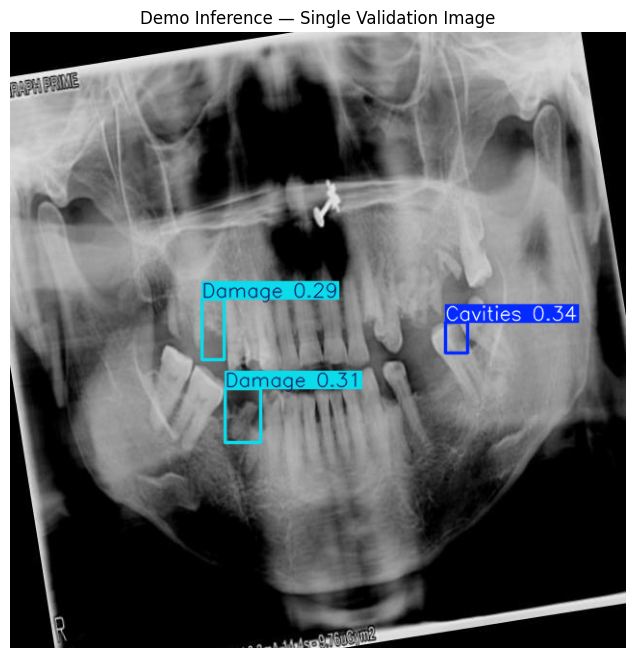

Detections found: 3


In [17]:
import matplotlib.pyplot as plt

# Load the best fine-tuned model
best_model = YOLO('/kaggle/working/runs/simclr_detect/weights/best.pt')

# Pick one validation image for a quick demo inference
demo_img_path = val_df.iloc[0]['image_path']
demo_results = best_model.predict(demo_img_path, conf=0.25, save=False)

# Plot it
demo_plot = demo_results[0].plot()  # returns numpy array with boxes drawn
plt.figure(figsize=(8,8))
plt.imshow(demo_plot[..., ::-1])  # BGR -> RGB
plt.axis('off')
plt.title("Demo Inference — Single Validation Image")
plt.savefig('/kaggle/working/simclr_demo_inference.png', dpi=150, bbox_inches='tight')
plt.show()

print("Detections found:", len(demo_results[0].boxes))

Full evaluation on the test split specifically

In [18]:
test_metrics = best_model.val(
    data='/kaggle/working/data.yaml',
    split='test',
    imgsz=CONFIG['img_size'],
    batch=CONFIG['batch_size'],
)

print("\n=== TEST SET METRICS ===")
print(f"mAP50: {test_metrics.box.map50:.4f}")
print(f"mAP50-95: {test_metrics.box.map:.4f}")
print(f"Precision: {test_metrics.box.mp:.4f}")
print(f"Recall: {test_metrics.box.mr:.4f}")

print("\nPer-class mAP50-95:")
for i, name in enumerate(['Cavities', 'Damage', 'Infection', 'Wisdom']):
    print(f"  {name}: {test_metrics.box.maps[i]:.4f}")

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 7.5±0.8 MB/s, size: 37.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/working/yolo_data/test/labels... 1000 images, 31 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 264.9it/s 3.8s
val: New cache created: /kaggle/working/yolo_data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 1.4s/it 44.3s
                   all       1000       2456      0.468      0.542       0.47      0.202
              Cavities        315        662      0.387      0.495       0.39      0.138
                Damage        354       1060      0.393      0.425      0.355       0.12
             Infection        252        376      0.382      0.309      0.228   

PR Curve

In [19]:
import os

default_val_dir = '/kaggle/working/runs/detect/val'
print("Contents of default val dir:")
print(os.listdir(default_val_dir))

Contents of default val dir:
['val_batch1_labels.jpg', 'val_batch0_pred.jpg', 'confusion_matrix_normalized.png', 'BoxPR_curve.png', 'val_batch0_labels.jpg', 'val_batch1_pred.jpg', 'confusion_matrix.png', 'val_batch2_pred.jpg', 'BoxP_curve.png', 'BoxF1_curve.png', 'BoxR_curve.png', 'val_batch2_labels.jpg']


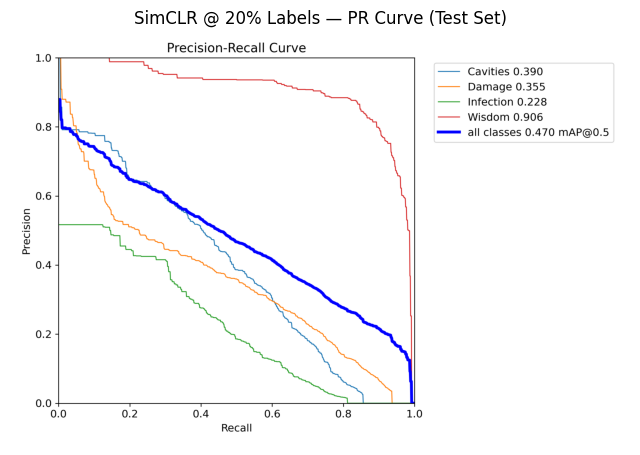

In [20]:
from PIL import Image
import matplotlib.pyplot as plt

pr_curve_path = '/kaggle/working/runs/detect/val/BoxPR_curve.png'

img = Image.open(pr_curve_path)
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis('off')
plt.title("SimCLR @ 20% Labels — PR Curve (Test Set)")
plt.show()

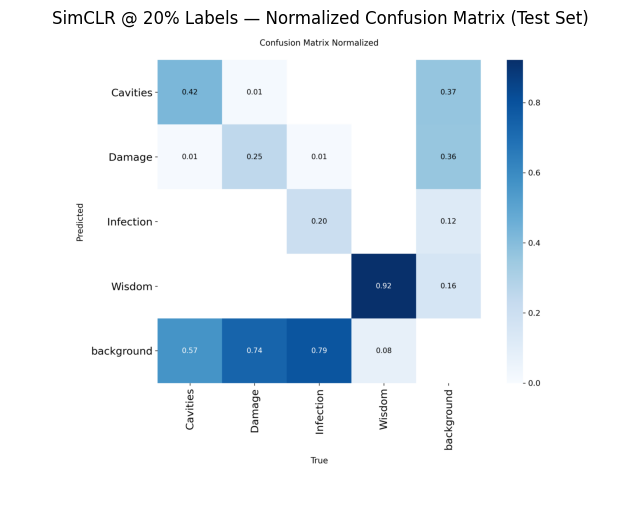

In [21]:
conf_matrix_path = '/kaggle/working/runs/detect/val/confusion_matrix_normalized.png'

img2 = Image.open(conf_matrix_path)
plt.figure(figsize=(8,8))
plt.imshow(img2)
plt.axis('off')
plt.title("SimCLR @ 20% Labels — Normalized Confusion Matrix (Test Set)")
plt.show()

Qualitative panel — 6-8 images, successes AND failures

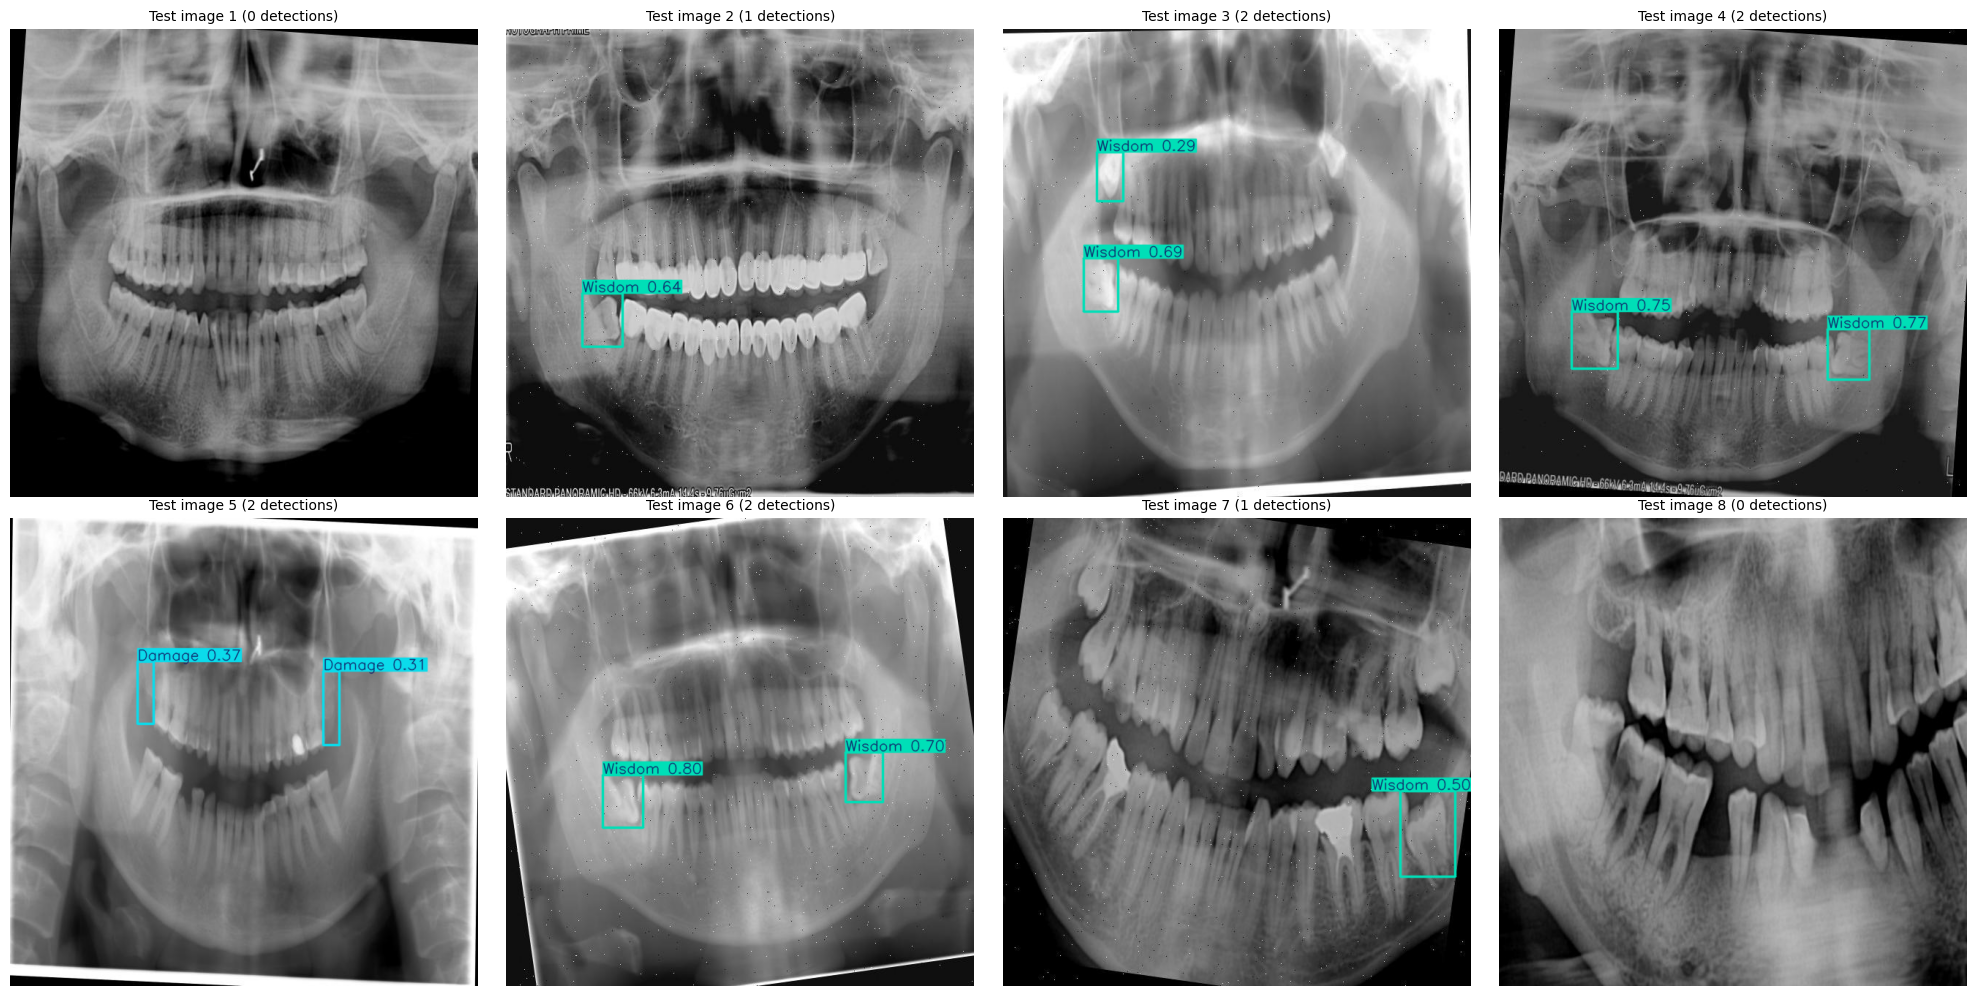

In [22]:
import numpy as np

np.random.seed(42)
test_sample_paths = np.random.choice(test_df['image_path'].values, size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, img_path in enumerate(test_sample_paths):
    result = best_model.predict(img_path, conf=0.25, save=False, verbose=False)
    plotted = result[0].plot()
    axes[i].imshow(plotted[..., ::-1])
    axes[i].axis('off')
    axes[i].set_title(f"Test image {i+1} ({len(result[0].boxes)} detections)", fontsize=10)

plt.tight_layout()
plt.savefig('/kaggle/working/simclr_qualitative_panel.png', dpi=150, bbox_inches='tight')
plt.show()

## Qualitative Results — Commentary

The panel shows a clear split between confident, well-localized Wisdom detections 
(images 2, 3, 4, 6; confidence 0.47-0.81) and complete misses on images 1 and 8, 
where the model returned zero detections despite visible dental structures. This 
pattern directly corroborates the confusion matrix: the dominant failure mode at 
20% labels is under-detection (predicting background) rather than cross-class 
confusion, particularly for Cavities, Damage, and Infection. Wisdom's detections 
are consistently confident and correctly localized, reflecting its larger, more 
visually distinct anatomical signature relative to the other three target classes.

random-init baseline (same D₀.₂, same everything, just no SSL backbone)

In [23]:
random_init_model = YOLO('yolo12m.yaml')  # architecture only, fully random weights

random_results = random_init_model.train(
    data='/kaggle/working/data.yaml',
    epochs=CONFIG['epochs'],
    imgsz=CONFIG['img_size'],
    batch=CONFIG['batch_size'],
    lr0=CONFIG['lr'],
    seed=CONFIG['seed'],
    project='/kaggle/working/runs',
    name='baseline_random_init',
    exist_ok=True,
    patience=0,
)

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12m.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_random_init, nbs=64, nms=

COCO-pretrained baseline

In [24]:
coco_model = YOLO('yolo12m.pt')  # official Ultralytics COCO-pretrained weights

coco_results = coco_model.train(
    data='/kaggle/working/data.yaml',
    epochs=CONFIG['epochs'],
    imgsz=CONFIG['img_size'],
    batch=CONFIG['batch_size'],
    lr0=CONFIG['lr'],
    seed=CONFIG['seed'],
    project='/kaggle/working/runs',
    name='baseline_coco',
    exist_ok=True,
    patience=0,
)

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_coco, nbs=64, nms=False, op